# Task 1 — классификация клинических рисков по табличным данным

Конвейер: EDA → стратифицированное разделение → импутация и стандартизация внутри `Pipeline` → сравнение моделей кросс-валидацией и подбор гиперпараметров → выбор порога по out-of-fold вероятностям → одна финальная оценка на отложенной выборке → обучение на всём train и прогноз для test → нечёткий KNN для пограничной глюкозы → отчёт.

Тестовые признаки не участвуют ни в обучении предобработки, ни в обучении моделей. Столбцы `Статус_глюкозы` и `Доклинический_риск` есть в `test_features.csv`, но это целевые переменные, поэтому они исключены из признаков везде.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, cross_val_predict, GridSearchCV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score,
    log_loss, balanced_accuracy_score,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
SEED = 42
np.random.seed(SEED)

## 1. Загрузка данных

In [2]:
repo_root = Path.cwd()
if repo_root.name in {'vanilla-code', 'your-sollution', 'your_solution'}:
    repo_root = repo_root.parent

local_dir = repo_root / 'dataset' / 'task1'
if (local_dir / 'train.csv').exists():
    data_dir = str(local_dir)
else:
    data_dir = ('https://github.com/AI-is-out-there/check-your-biomed-datascience-skills-review/'
                'raw/refs/heads/main/dataset/task1')

df = pd.read_csv(f'{data_dir}/train.csv')
test = pd.read_csv(f'{data_dir}/test_features.csv')

fig_dir = repo_root / 'outputs' / 'task1_figures'
fig_dir.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(fig_dir / name, dpi=110, bbox_inches='tight')


ID = 'patient_id'
TARGET = 'prediction'
GLU_STATUS = 'Статус_глюкозы'
TARGETS = [TARGET, GLU_STATUS, 'Доклинический_риск']
FEATURES = [c for c in df.columns if c not in TARGETS + [ID]]
BINARY = [c for c in FEATURES if df[c].dropna().isin([0, 1]).all()]
NUMERIC = [c for c in FEATURES if c not in BINARY]
GLU = 'Глюкоза_натощак_ммоль_л'

print('train:', df.shape, '| test:', test.shape)
print('признаки:', len(FEATURES), '| бинарные:', BINARY)
assert set(FEATURES) <= set(test.columns)
assert df[ID].is_unique and test[ID].is_unique

train: (800, 19) | test: (200, 18)
признаки: 15 | бинарные: ['Пол_мужской', 'Курение']


## 2. Исследовательский анализ

In [3]:
missing = pd.DataFrame({
    'train_n': df[FEATURES].isna().sum(),
    'train_%': df[FEATURES].isna().mean() * 100,
    'test_n': test[FEATURES].isna().sum(),
})
missing = missing[missing.train_n + missing.test_n > 0]
missing['доля риска при пропуске'] = [df.loc[df[c].isna(), TARGET].mean() for c in missing.index]
missing['доля риска без пропуска'] = [df.loc[df[c].notna(), TARGET].mean() for c in missing.index]
display(missing)
display(df[FEATURES].describe().T)

,train_n,train_%,test_n,доля риска при пропуске,доля риска без пропуска
ЛПНП_ммоль_л,35,4.375,10,0.114,0.184
ЛПВП_ммоль_л,45,5.625,11,0.156,0.183
Триглицериды_ммоль_л,46,5.750,15,0.217,0.179
СКФ_мл_мин,47,5.875,14,0.191,0.181


,count,mean,std,min,25%,50%,75%,max
Возраст,800.000,52.256,7.563,40.000,45.000,53.000,59.000,65.000
Пол_мужской,800.000,0.446,0.497,0.000,0.000,0.000,1.000,1.000
ИМТ,800.000,23.568,3.229,16.000,21.120,23.595,26.035,33.890
Окружность_талии_см,800.000,86.178,6.026,68.860,81.968,86.160,90.505,104.630
САД_мм_рт_ст,800.000,114.084,11.162,90.000,106.627,114.475,121.957,147.970
ДАД_мм_рт_ст,800.000,70.346,7.099,50.000,65.450,70.435,75.028,90.620
Пульсовое_давление,800.000,43.738,10.345,9.060,36.847,43.895,50.398,73.950
Глюкоза_натощак_ммоль_л,800.000,5.070,0.769,3.500,4.534,5.006,5.603,7.348
HbA1c_%,800.000,5.019,0.365,4.000,4.780,5.010,5.280,6.020
ЛПНП_ммоль_л,765.000,2.983,0.643,1.207,2.556,2.987,3.415,5.115


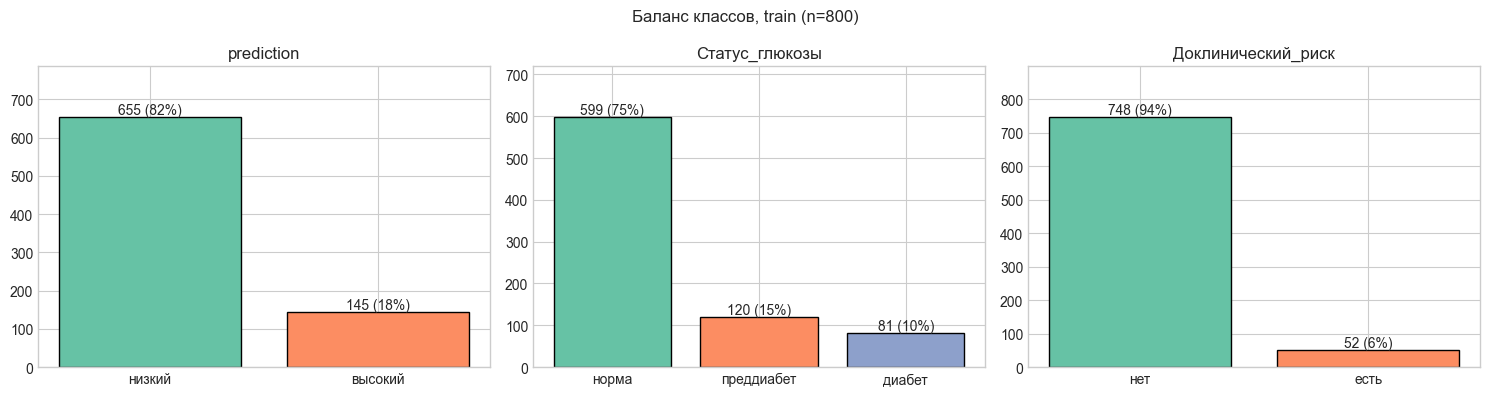

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = {
    TARGET: ['низкий', 'высокий'],
    GLU_STATUS: ['норма', 'преддиабет', 'диабет'],
    'Доклинический_риск': ['нет', 'есть'],
}
for ax, col in zip(axes, TARGETS):
    vc = df[col].value_counts().sort_index()
    ax.bar(names[col], vc.values, color=sns.color_palette('Set2', len(vc)), edgecolor='black')
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v} ({v / len(df):.0%})', ha='center', va='bottom')
    ax.set_ylim(0, vc.max() * 1.2)
    ax.set_title(col)
fig.suptitle('Баланс классов, train (n=800)')
plt.tight_layout(); save(fig, '01_class_balance.png'); plt.show()

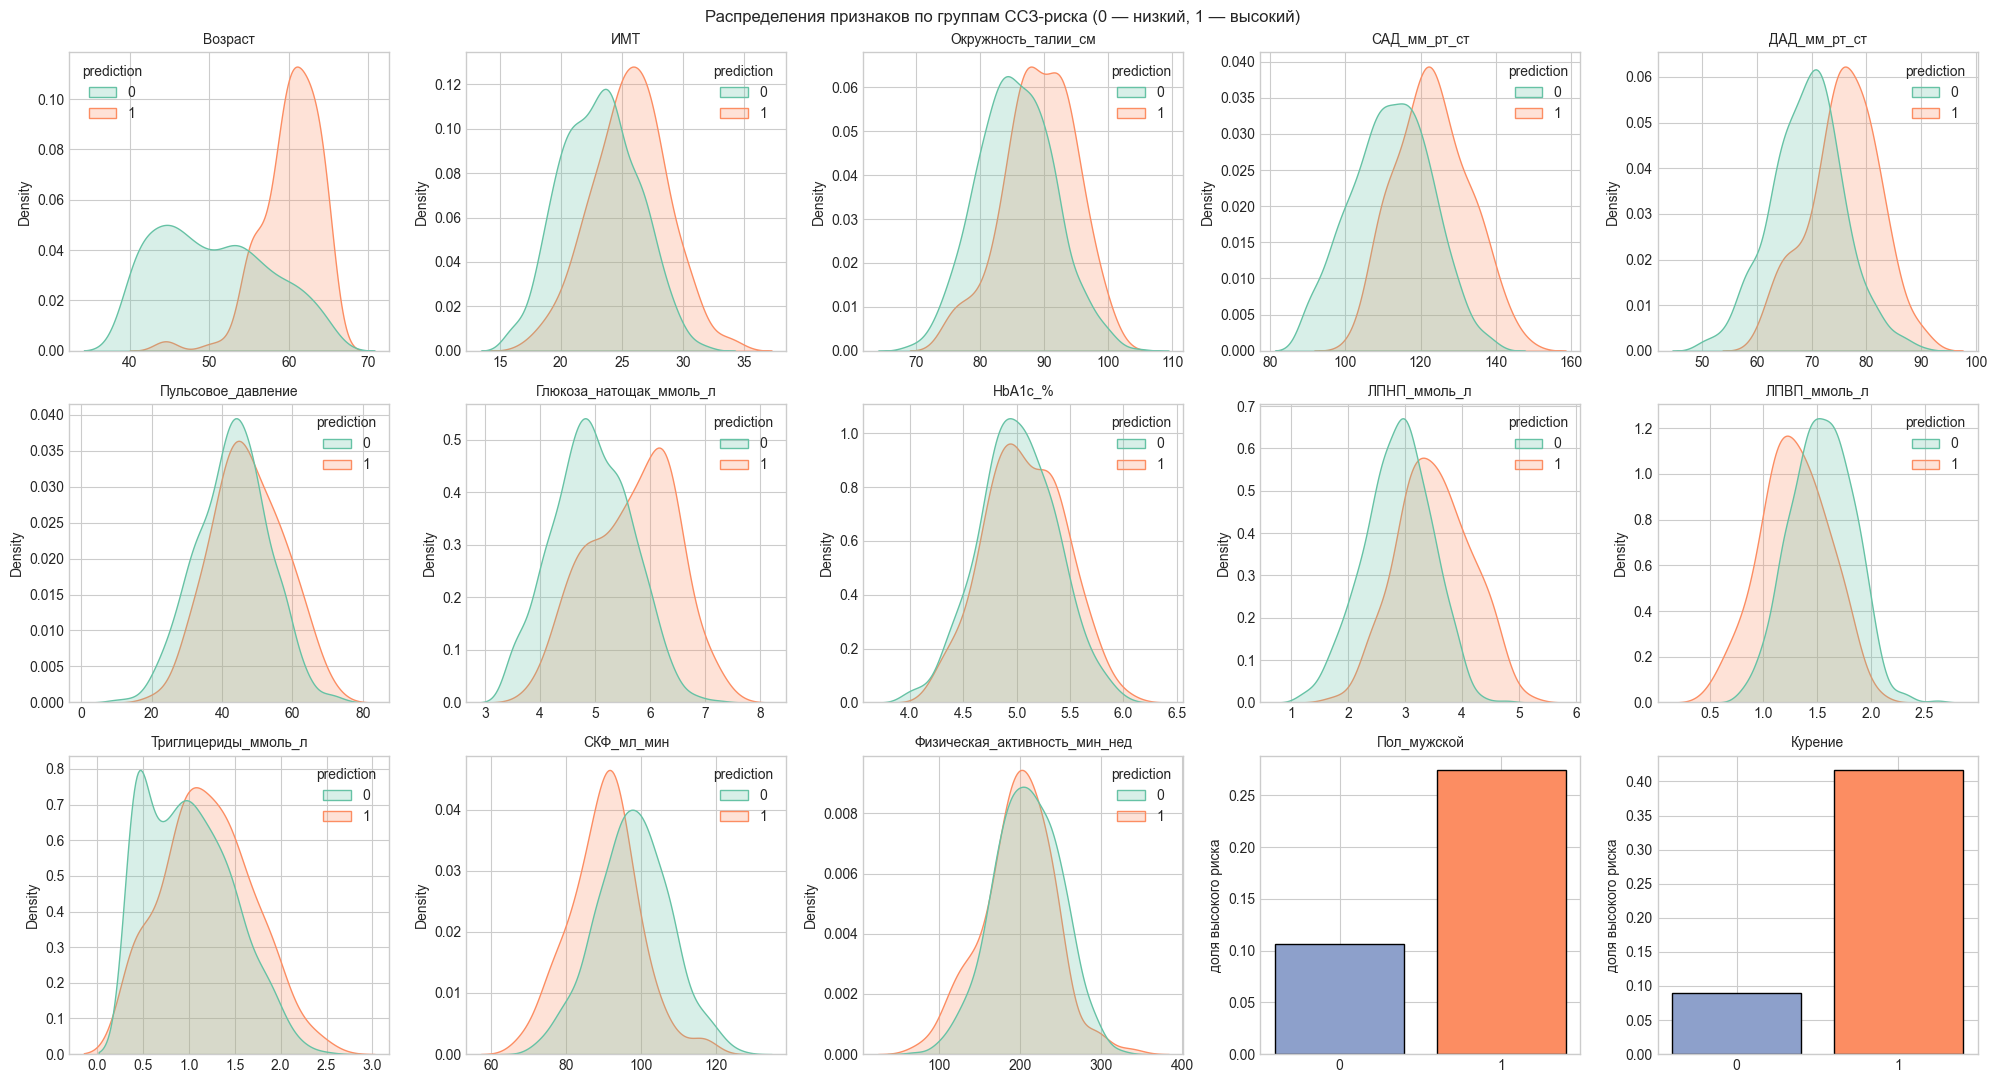

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.flat, NUMERIC + BINARY):
    if col in BINARY:
        rate = df.groupby(col)[TARGET].mean()
        ax.bar(rate.index.astype(str), rate.values, color=['#8da0cb', '#fc8d62'], edgecolor='black')
        ax.set_ylabel('доля высокого риска')
    else:
        sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, ax=ax,
                    palette={0: '#66c2a5', 1: '#fc8d62'})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for ax in axes.flat[len(FEATURES):]:
    ax.axis('off')
fig.suptitle('Распределения признаков по группам ССЗ-риска (0 — низкий, 1 — высокий)')
plt.tight_layout(); save(fig, '02_feature_distributions.png'); plt.show()

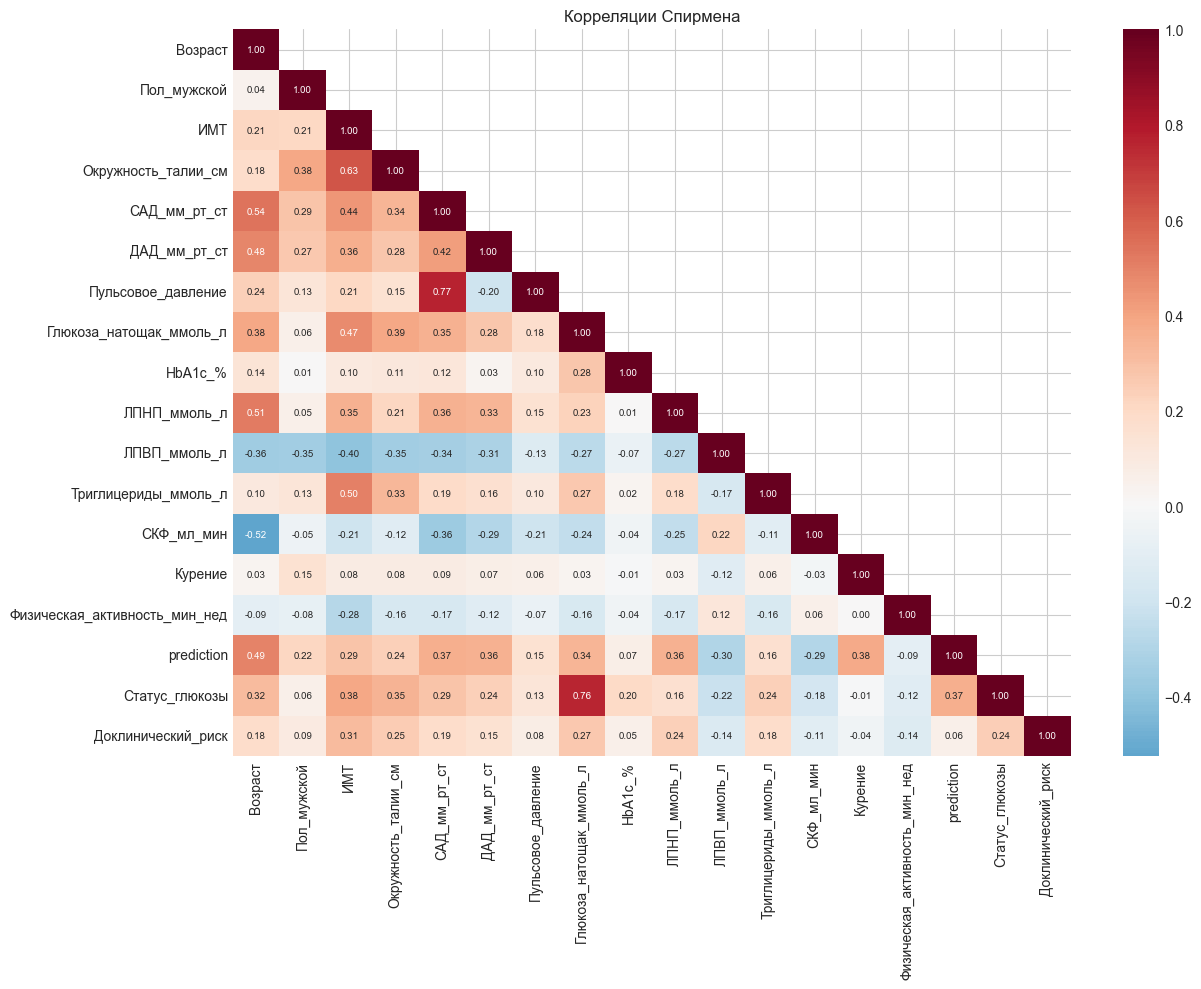

,rho с prediction
Возраст,0.494
Курение,0.381
САД_мм_рт_ст,0.366
ЛПНП_ммоль_л,0.356
ДАД_мм_рт_ст,0.356
Глюкоза_натощак_ммоль_л,0.337
ЛПВП_ммоль_л,-0.296
СКФ_мл_мин,-0.291
ИМТ,0.288
Окружность_талии_см,0.243


In [6]:
corr = df[FEATURES + TARGETS].corr(method='spearman')
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1), ax=ax)
ax.set_title('Корреляции Спирмена')
plt.tight_layout(); save(fig, '03_correlation.png'); plt.show()
display(corr[TARGET].drop(TARGETS).sort_values(key=abs, ascending=False).to_frame('rho с prediction'))

In [7]:
status_bounds = df.groupby(GLU_STATUS)[GLU].agg(['min', 'max', 'count'])
display(status_bounds)

,min,max,count
Статус_глюкозы,,,
0,3.500,5.590,599
1,5.601,6.096,120
2,6.113,7.348,81


**Наблюдения.** Высокий ССЗ-риск — 18% (145/800), то есть дисбаланс примерно 1:4.5. Наиболее связаны с риском возраст, ЛПНП, САД, курение, глюкоза, ДАД, ИМТ; с обратным знаком — ЛПВП и СКФ. Пары ИМТ–окружность талии и САД–пульсовое давление сильно коррелируют между собой. Пропуски (4–6%) есть только в четырёх лабораторных показателях. `Статус_глюкозы` в данных задан жёсткими порогами глюкозы натощак (≈5.6 и ≈6.1 ммоль/л), поэтому в пограничной зоне 5.4–6.5 метка зависит от малых колебаний одного измерения — именно здесь полезна нечёткая оценка.

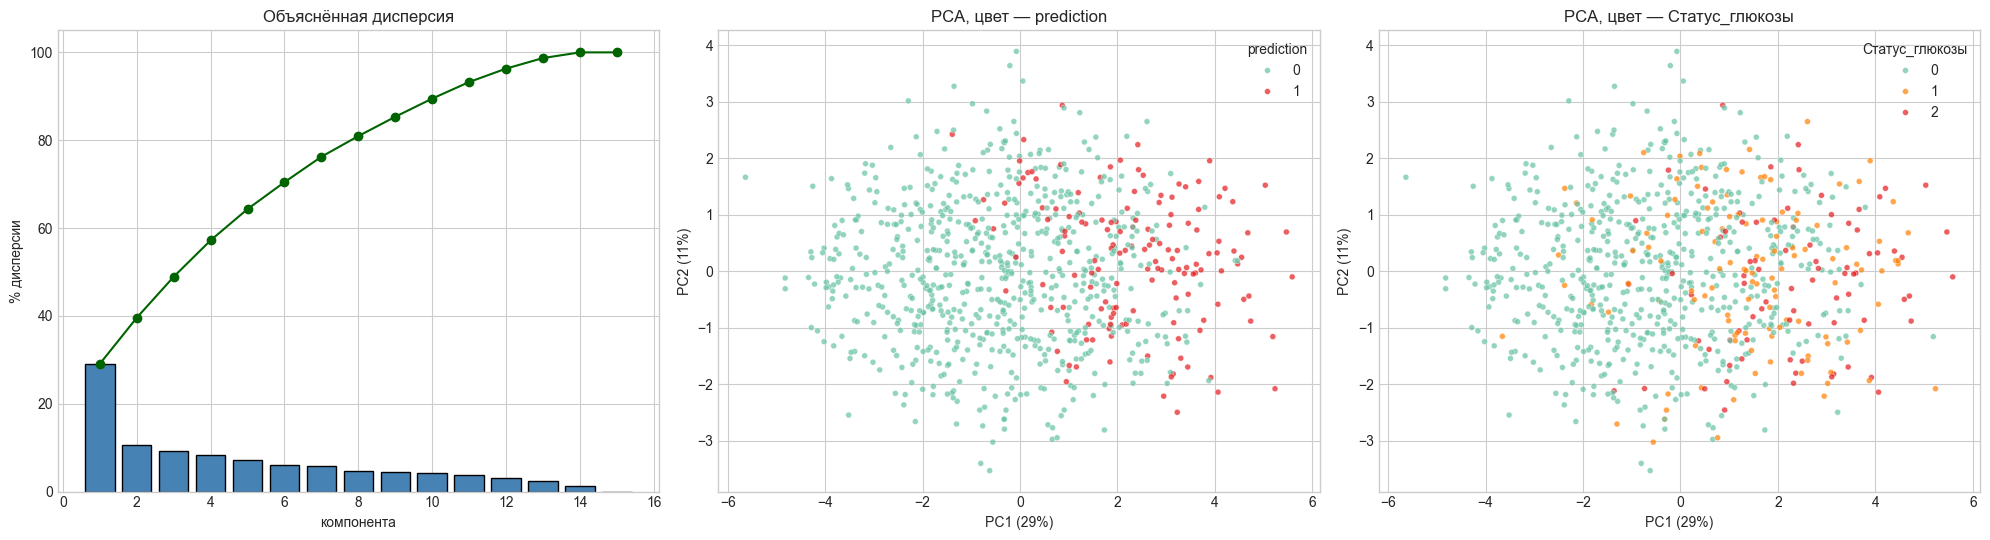

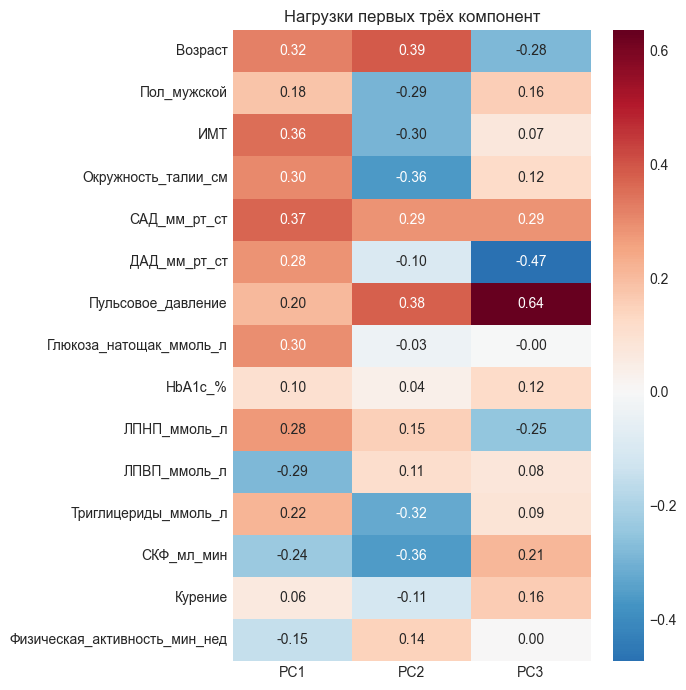

In [8]:
pca_pipe = Pipeline([
    ('imp', IterativeImputer(random_state=SEED, max_iter=20)),
    ('sc', StandardScaler()),
    ('pca', PCA(random_state=SEED)),
])
Z = pca_pipe.fit_transform(df[FEATURES])
pca = pca_pipe.named_steps['pca']
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
axes[0].bar(range(1, len(evr) + 1), evr * 100, color='steelblue', edgecolor='black')
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, 'o-', color='darkgreen')
axes[0].set_xlabel('компонента'); axes[0].set_ylabel('% дисперсии')
axes[0].set_title('Объяснённая дисперсия')
for ax, col, pal in [(axes[1], TARGET, {0: '#66c2a5', 1: '#e41a1c'}),
                     (axes[2], GLU_STATUS, {0: '#66c2a5', 1: '#ff7f00', 2: '#e41a1c'})]:
    sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=df[col], palette=pal, s=18, alpha=0.7, ax=ax)
    ax.set_xlabel(f'PC1 ({evr[0]:.0%})'); ax.set_ylabel(f'PC2 ({evr[1]:.0%})')
    ax.set_title(f'PCA, цвет — {col}')
plt.tight_layout(); save(fig, '04_pca.png'); plt.show()

loadings = pd.DataFrame(pca.components_[:3].T, index=FEATURES, columns=['PC1', 'PC2', 'PC3'])
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Нагрузки первых трёх компонент')
plt.tight_layout(); save(fig, '05_pca_loadings.png'); plt.show()

## 3. Классификатор ССЗ-риска (`prediction`)

1. Стратифицированное разделение train на 80% обучения и 20% отложенной выборки; отложенная выборка используется ровно один раз — в финальной оценке.
2. Импутация (`IterativeImputer` с индикаторами пропусков) и стандартизация находятся внутри `Pipeline`, поэтому на каждом фолде они обучаются только на обучающей части.
3. Модели сравниваются по ROC-AUC на 5×3 повторной стратифицированной кросс-валидации, гиперпараметры подбираются `GridSearchCV`.
4. Дисбаланс учитывается через `class_weight='balanced'` и выбор порога.

In [9]:
X = df[FEATURES]
y = df[TARGET].values
X_tr, X_ho, y_tr, y_ho = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'обучение: {len(y_tr)} (риск {y_tr.mean():.1%}) | отложенная: {len(y_ho)} (риск {y_ho.mean():.1%})')


def make_pipe(clf):
    return Pipeline([
        ('imp', IterativeImputer(random_state=SEED, max_iter=20, add_indicator=True)),
        ('sc', StandardScaler()),
        ('clf', clf),
    ])


cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

candidates = {
    'LogReg': LogisticRegression(class_weight='balanced', max_iter=5000),
    'SVM RBF': SVC(class_weight='balanced', probability=True, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                           min_samples_leaf=3, random_state=SEED, n_jobs=-1),
    'HistGB': HistGradientBoostingClassifier(class_weight='balanced', max_depth=3,
                                             learning_rate=0.05, max_iter=300, random_state=SEED),
}
rows = []
for name, clf in candidates.items():
    s = cross_val_score(make_pipe(clf), X_tr, y_tr, cv=rcv, scoring='roc_auc', n_jobs=-1)
    rows.append({'модель': name, 'ROC-AUC mean': s.mean(), 'ROC-AUC std': s.std()})
cv_table = pd.DataFrame(rows).sort_values('ROC-AUC mean', ascending=False)
display(cv_table)

обучение: 640 (риск 18.1%) | отложенная: 160 (риск 18.1%)


,модель,ROC-AUC mean,ROC-AUC std
3,HistGB,0.995,0.004
2,RandomForest,0.978,0.010
0,LogReg,0.968,0.011
1,SVM RBF,0.961,0.013


In [10]:
grids = {
    'LogReg': (LogisticRegression(class_weight='balanced', max_iter=5000),
               {'clf__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}),
    'SVM': (SVC(class_weight='balanced', probability=True, random_state=SEED),
            [{'clf__kernel': ['linear'], 'clf__C': [0.003, 0.01, 0.03, 0.1, 0.3]},
             {'clf__kernel': ['rbf'], 'clf__C': [0.1, 0.3, 1, 3, 10],
              'clf__gamma': ['scale', 0.003, 0.01, 0.03]}]),
    'HistGB': (HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED),
               {'clf__max_depth': [2, 3, 4], 'clf__learning_rate': [0.03, 0.1],
                'clf__max_iter': [200, 400], 'clf__l2_regularization': [0.0, 1.0]}),
}
searches = {}
for name, (clf, grid) in grids.items():
    gs = GridSearchCV(make_pipe(clf), grid, cv=rcv, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    searches[name] = gs
    print(f'{name:7s} ROC-AUC CV = {gs.best_score_:.4f} | {gs.best_params_}')

best_name = max(searches, key=lambda k: searches[k].best_score_)
best_params = searches[best_name].best_params_
best_clf = searches[best_name].best_estimator_.named_steps['clf']
print('выбрана модель:', best_name, best_params)

LogReg  ROC-AUC CV = 0.9686 | {'clf__C': 0.3}


SVM     ROC-AUC CV = 0.9713 | {'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}


HistGB  ROC-AUC CV = 0.9969 | {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__max_iter': 400}
выбрана модель: HistGB {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__max_iter': 400}


### Выбор порога

Порог 0.5 при дисбалансе произволен. В скрининге пропуск пациента высокого риска (FN) обходится дороже ложной тревоги (FP), поэтому правило такое: **максимальный F1 среди порогов, при которых recall ≥ 0.90**. Порог считается только по out-of-fold вероятностям на обучающей части, отложенная выборка в этом не участвует.

порог = 0.42


,threshold,Accuracy,Recall,Specificity,Precision,F1,TP,FN,FP,TN
25,0.300,0.978,0.983,0.977,0.905,0.942,114,2,12,512
35,0.400,0.983,0.974,0.985,0.934,0.954,113,3,8,516
37,0.420,0.986,0.974,0.989,0.950,0.962,113,3,6,518
45,0.500,0.984,0.966,0.989,0.949,0.957,112,4,6,518


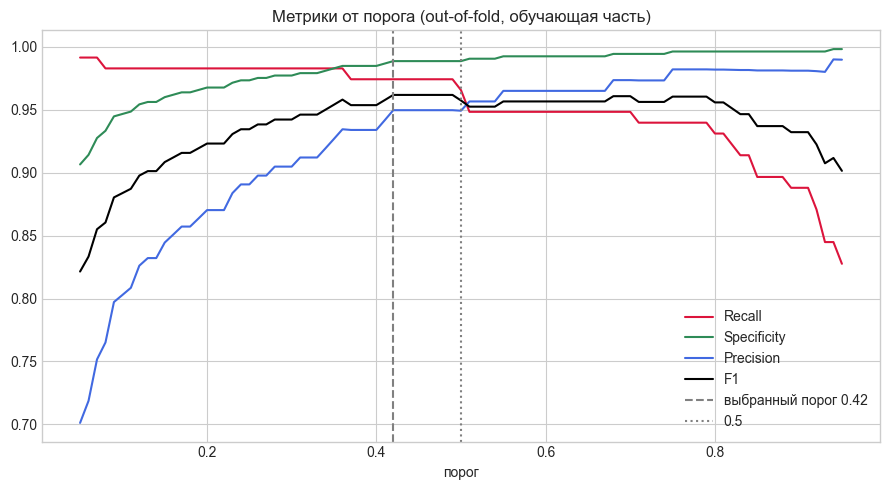

In [11]:
oof = cross_val_predict(make_pipe(best_clf), X_tr, y_tr, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]


def metrics_at(y_true, proba, t):
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'threshold': t,
        'Accuracy': (tp + tn) / len(pred),
        'Recall': tp / (tp + fn) if tp + fn else 0.0,
        'Specificity': tn / (tn + fp) if tn + fp else 0.0,
        'Precision': tp / (tp + fp) if tp + fp else 0.0,
        'F1': 2 * tp / (2 * tp + fp + fn) if tp else 0.0,
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
    }


curve = pd.DataFrame([metrics_at(y_tr, oof, t) for t in np.round(np.arange(0.05, 0.951, 0.01), 2)])
eligible = curve[curve.Recall >= 0.90]
THRESHOLD = float(eligible.loc[eligible.F1.idxmax(), 'threshold']) if len(eligible) else 0.5
print(f'порог = {THRESHOLD:.2f}')
display(curve[curve.threshold.isin([0.3, 0.4, 0.5, THRESHOLD])].drop_duplicates('threshold'))

fig, ax = plt.subplots(figsize=(9, 5))
for m, c in [('Recall', 'crimson'), ('Specificity', 'seagreen'), ('Precision', 'royalblue'), ('F1', 'black')]:
    ax.plot(curve.threshold, curve[m], label=m, color=c)
ax.axvline(THRESHOLD, ls='--', color='grey', label=f'выбранный порог {THRESHOLD:.2f}')
ax.axvline(0.5, ls=':', color='grey', label='0.5')
ax.set_xlabel('порог'); ax.set_title('Метрики от порога (out-of-fold, обучающая часть)')
ax.legend()
plt.tight_layout(); save(fig, '06_threshold.png'); plt.show()

### Финальная оценка на отложенной выборке

In [12]:
model_ho = make_pipe(best_clf).fit(X_tr, y_tr)
proba_ho = model_ho.predict_proba(X_ho)[:, 1]
pred_ho = (proba_ho >= THRESHOLD).astype(int)

baseline = Pipeline([('imp', IterativeImputer(random_state=SEED)), ('sc', StandardScaler()),
                     ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED))])
base_proba = baseline.fit(X_tr, y_tr).predict_proba(X_ho)[:, 1]
base_pred = baseline.predict(X_ho)

summary = pd.DataFrame({
    f'{best_name}, порог {THRESHOLD:.2f}': metrics_at(y_ho, proba_ho, THRESHOLD),
    f'{best_name}, порог 0.50': metrics_at(y_ho, proba_ho, 0.5),
    'базовая SVM RBF': {**metrics_at(y_ho, base_pred.astype(float), 0.5), 'threshold': np.nan},
}).T
summary['ROC-AUC'] = [roc_auc_score(y_ho, proba_ho)] * 2 + [roc_auc_score(y_ho, base_proba)]
summary['PR-AUC'] = [average_precision_score(y_ho, proba_ho)] * 2 + [average_precision_score(y_ho, base_proba)]
display(summary)

,threshold,Accuracy,Recall,Specificity,Precision,F1,TP,FN,FP,TN,ROC-AUC,PR-AUC
"HistGB, порог 0.42",0.420,1.000,1.000,1.000,1.000,1.000,29.000,0.000,0.000,131.000,1.000,1.000
"HistGB, порог 0.50",0.500,1.000,1.000,1.000,1.000,1.000,29.000,0.000,0.000,131.000,1.000,1.000
базовая SVM RBF,NaN,0.925,0.931,0.924,0.730,0.818,27.000,2.000,10.000,121.000,0.989,0.957


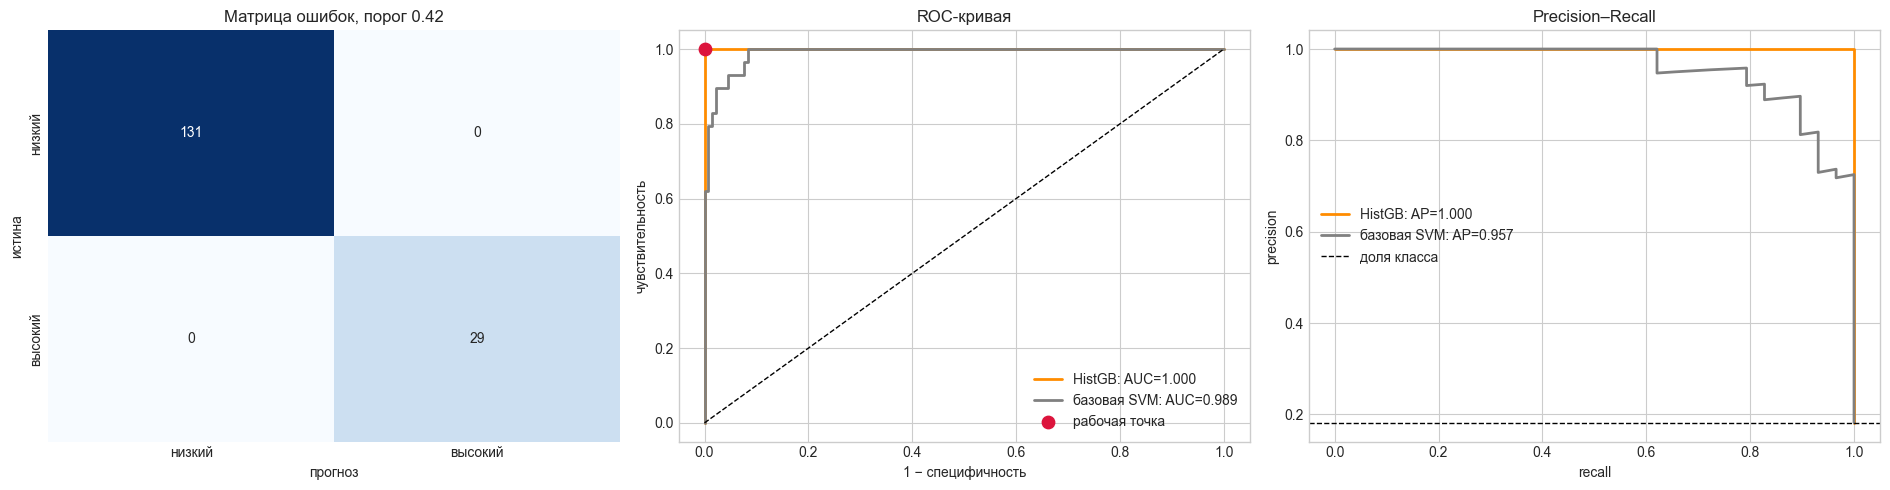

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
cm = confusion_matrix(y_ho, pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['низкий', 'высокий'], yticklabels=['низкий', 'высокий'])
axes[0].set_xlabel('прогноз'); axes[0].set_ylabel('истина')
axes[0].set_title(f'Матрица ошибок, порог {THRESHOLD:.2f}')

for proba, label, c in [(proba_ho, best_name, 'darkorange'), (base_proba, 'базовая SVM', 'grey')]:
    fpr, tpr, _ = roc_curve(y_ho, proba)
    axes[1].plot(fpr, tpr, lw=2, color=c, label=f'{label}: AUC={roc_auc_score(y_ho, proba):.3f}')
    p, r, _ = precision_recall_curve(y_ho, proba)
    axes[2].plot(r, p, lw=2, color=c, label=f'{label}: AP={average_precision_score(y_ho, proba):.3f}')
op = metrics_at(y_ho, proba_ho, THRESHOLD)
axes[1].scatter(1 - op['Specificity'], op['Recall'], s=80, color='crimson', zorder=3, label='рабочая точка')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('1 − специфичность'); axes[1].set_ylabel('чувствительность')
axes[1].set_title('ROC-кривая'); axes[1].legend(loc='lower right')
axes[2].axhline(y_ho.mean(), ls='--', color='k', lw=1, label='доля класса')
axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision')
axes[2].set_title('Precision–Recall'); axes[2].legend()
plt.tight_layout(); save(fig, '07_holdout_eval.png'); plt.show()

### Важность признаков и разбор ошибок

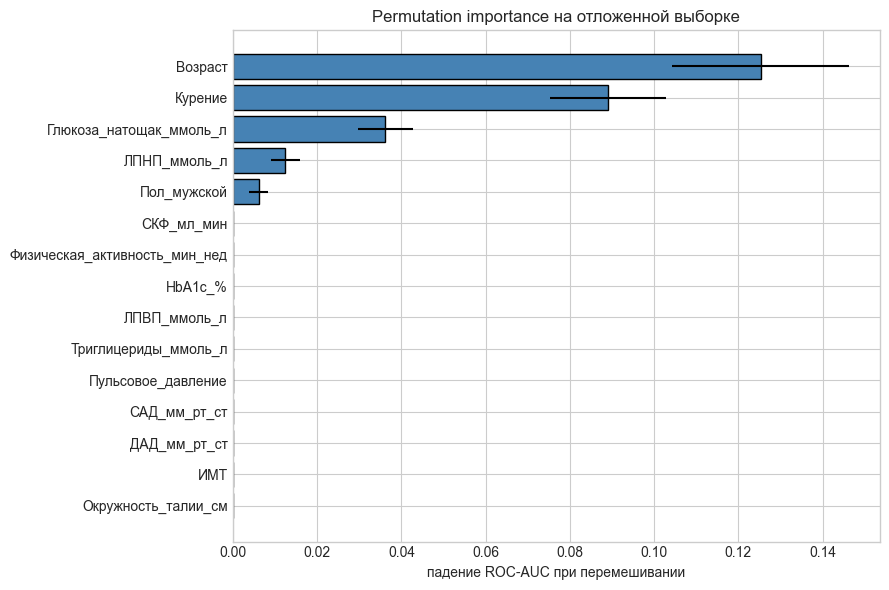

,mean,std
Возраст,0.125,0.021
Курение,0.089,0.014
Глюкоза_натощак_ммоль_л,0.036,0.007
ЛПНП_ммоль_л,0.012,0.003
Пол_мужской,0.006,0.002
ИМТ,0.000,0.000
Окружность_талии_см,0.000,0.000
ЛПВП_ммоль_л,0.000,0.000


In [14]:
perm = permutation_importance(model_ho, X_ho, y_ho, scoring='roc_auc', n_repeats=30,
                              random_state=SEED, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp_std = pd.Series(perm.importances_std, index=FEATURES)[imp.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, xerr=imp_std.values, color='steelblue', edgecolor='black')
ax.set_xlabel('падение ROC-AUC при перемешивании')
ax.set_title('Permutation importance на отложенной выборке')
plt.tight_layout(); save(fig, '08_feature_importance.png'); plt.show()
display(pd.DataFrame({'mean': imp, 'std': imp_std}).sort_values('mean', ascending=False).head(8))

if hasattr(model_ho.named_steps['clf'], 'coef_'):
    coef_names = model_ho.named_steps['imp'].get_feature_names_out(FEATURES)
    coef = pd.Series(model_ho.named_steps['clf'].coef_.ravel(), index=coef_names)
    display(coef.sort_values(key=abs, ascending=False).head(10).to_frame('коэффициент (станд.)'))

In [15]:
err = X_ho.copy()
err['y'] = y_ho
err['proba'] = proba_ho
err['тип'] = np.select(
    [(y_ho == 1) & (pred_ho == 1), (y_ho == 0) & (pred_ho == 0), (y_ho == 1) & (pred_ho == 0)],
    ['TP', 'TN', 'FN'], 'FP')
display(err.groupby('тип')[['Возраст', 'САД_мм_рт_ст', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л',
                            'Курение', GLU, 'proba']].mean())
display(err[err['тип'] == 'FN'][FEATURES + ['proba']])

,Возраст,САД_мм_рт_ст,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Курение,Глюкоза_натощак_ммоль_л,proba
тип,,,,,,,
TN,50.702,112.396,2.869,1.595,0.191,4.983,0.010
TP,60.207,123.134,3.443,1.297,0.724,5.606,0.990


,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,proba


### Обучение на всех 800 пациентах и прогноз для test

In [16]:
final_model = make_pipe(best_clf).fit(X, y)
test_proba = final_model.predict_proba(test[FEATURES])[:, 1]
test_pred = (test_proba >= THRESHOLD).astype(int)

submission = pd.DataFrame({ID: test[ID].values, TARGET: test_pred})
assert len(submission) == len(test)
assert submission[ID].tolist() == test[ID].tolist()
assert submission.notna().all().all()
assert set(submission[TARGET].unique()) <= {0, 1}

out_dir = repo_root / 'outputs'
submission.to_csv(out_dir / 'task1_predictions.csv', index=False)
pd.DataFrame({ID: test[ID].values, 'proba_high_risk': test_proba.round(4), TARGET: test_pred}).to_csv(
    out_dir / 'task1_test_probabilities.csv', index=False)
print(f'сохранено {len(submission)} строк, доля прогнозов высокого риска {test_pred.mean():.1%}')
display(submission.head())

сохранено 200 строк, доля прогнозов высокого риска 17.5%


,patient_id,prediction
0,2,0
1,3,1
2,8,0
3,18,0
4,19,1


## 4. Нечёткий KNN для пограничной глюкозы (5.4–6.5 ммоль/л)

Целевая переменная — `Статус_глюкозы` (норма / преддиабет / диабет), как в базовом ноутбуке. Что изменено относительно базовой версии:

- **Fuzzy KNN по Keller (1985).** Обучающие пациенты получают не жёсткие метки, а начальные степени принадлежности по своим `k_init` соседям: `0.51 + 0.49·n_c/k_init` для собственного класса и `0.49·n_c/k_init` для остальных. Итоговая принадлежность — среднее принадлежностей k соседей с весами `1/d^(2/(m−1))`.
- **Признаки.** Глюкоза, HbA1c, ИМТ, окружность талии, триглицериды, ЛПВП. Так как статус задан порогами глюкозы, у глюкозы в метрике расстояния повышенный вес `w`; `w`, `k`, `m` подбираются кросс-валидацией по log-loss.
- **Без утечек.** Импутер и масштабатор обучаются только на обучающих пограничных пациентах; финальная модель применяется к тестовым пограничным пациентам без использования их меток.
- **Скор риска** `= 0.5·μ(преддиабет) + 1.0·μ(диабет)`; **неопределённость** — нормированная энтропия принадлежностей; случай считается неопределённым, если максимальная принадлежность < 0.7.

In [17]:
FUZZY_FEATURES = [GLU, 'HbA1c_%', 'ИМТ', 'Окружность_талии_см', 'Триглицериды_ммоль_л', 'ЛПВП_ммоль_л']
CLASS_NAMES = ['норма', 'преддиабет', 'диабет']


class FuzzyKNN:
    def __init__(self, k=7, m=2.0, k_init=7, glu_weight=3.0):
        self.k, self.m, self.k_init, self.glu_weight = k, m, k_init, glu_weight

    def _prep(self, X):
        Z = self.scaler_.transform(self.imputer_.transform(X))
        Z[:, 0] *= self.glu_weight
        return Z

    def fit(self, X, y):
        self.imputer_ = IterativeImputer(random_state=SEED, max_iter=20).fit(X)
        self.scaler_ = StandardScaler().fit(self.imputer_.transform(X))
        self.X_ = self._prep(X)
        self.y_ = np.asarray(y).astype(int)
        self.n_classes_ = 3
        if self.k_init == 0:
            self.U_ = np.eye(self.n_classes_)[self.y_]
            return self
        d = np.linalg.norm(self.X_[:, None, :] - self.X_[None, :, :], axis=2)
        np.fill_diagonal(d, np.inf)
        nn = np.argsort(d, axis=1)[:, :self.k_init]
        counts = np.stack([(self.y_[nn] == c).sum(1) for c in range(self.n_classes_)], axis=1)
        U = 0.49 * counts / self.k_init
        U[np.arange(len(self.y_)), self.y_] += 0.51
        self.U_ = U
        return self

    def predict_membership(self, X):
        Z = self._prep(X)
        d = np.linalg.norm(Z[:, None, :] - self.X_[None, :, :], axis=2)
        nn = np.argsort(d, axis=1)[:, :self.k]
        dn = np.maximum(np.take_along_axis(d, nn, axis=1), 1e-9)
        w = dn ** (-2.0 / (self.m - 1.0))
        mu = np.einsum('ij,ijc->ic', w, self.U_[nn]) / w.sum(1, keepdims=True)
        return mu / mu.sum(1, keepdims=True)

    def predict(self, X):
        return self.predict_membership(X).argmax(1)


def risk_and_uncertainty(mu):
    risk = 0.5 * mu[:, 1] + 1.0 * mu[:, 2]
    p = np.clip(mu, 1e-12, 1)
    entropy = -(p * np.log(p)).sum(1) / np.log(mu.shape[1])
    return risk, entropy, mu.max(1) < 0.7


border = df[df[GLU].between(5.4, 6.5)].reset_index(drop=True)
Xb, yb = border[FUZZY_FEATURES], border[GLU_STATUS].values
print(f'пограничных пациентов в train: {len(border)}', dict(zip(CLASS_NAMES, np.bincount(yb).tolist())))
Xb_tr, Xb_ho, yb_tr, yb_ho = train_test_split(Xb, yb, test_size=0.3, stratify=yb, random_state=SEED)

пограничных пациентов в train: 247 {'норма': 69, 'преддиабет': 120, 'диабет': 58}


In [18]:
def cv_logloss(params, X, y):
    losses = []
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y):
        mdl = FuzzyKNN(**params).fit(X.iloc[tr], y[tr])
        losses.append(log_loss(y[va], np.clip(mdl.predict_membership(X.iloc[va]), 1e-6, 1), labels=[0, 1, 2]))
    return np.mean(losses)


grid = [dict(k=k, m=m, k_init=ki, glu_weight=w)
        for k in [5, 7, 11, 15] for m in [1.5, 2.0, 3.0] for w in [1.0, 3.0, 5.0, 8.0, 12.0] for ki in [0, 7]]
search = pd.DataFrame([{**g, 'logloss': cv_logloss(g, Xb_tr, yb_tr)} for g in grid]).sort_values('logloss')
display(search.head(8))
best_fuzzy = search.iloc[0][['k', 'm', 'k_init', 'glu_weight']].to_dict()
best_fuzzy = {'k': int(best_fuzzy['k']), 'm': float(best_fuzzy['m']),
              'k_init': int(best_fuzzy['k_init']), 'glu_weight': float(best_fuzzy['glu_weight'])}
print('выбрано:', best_fuzzy)

,k,m,k_init,glu_weight,logloss
38,7,1.500,0,12.000,0.049
8,5,1.500,0,12.000,0.050
18,5,2.000,0,12.000,0.052
48,7,2.000,0,12.000,0.052
28,5,3.000,0,12.000,0.054
58,7,3.000,0,12.000,0.055
68,11,1.500,0,12.000,0.055
98,15,1.500,0,12.000,0.058


выбрано: {'k': 7, 'm': 1.5, 'k_init': 0, 'glu_weight': 12.0}


In [19]:
base_fuzzy = FuzzyKNN(k=7, m=2.0, k_init=0, glu_weight=1.0).fit(Xb_tr, yb_tr)
fuzzy = FuzzyKNN(**best_fuzzy).fit(Xb_tr, yb_tr)
mu_ho = fuzzy.predict_membership(Xb_ho)
risk_ho, ent_ho, unc_ho = risk_and_uncertainty(mu_ho)
hard_ho = mu_ho.argmax(1)


def fuzzy_metrics(y_true, mu):
    return {
        'Accuracy': accuracy_score(y_true, mu.argmax(1)),
        'Balanced acc.': balanced_accuracy_score(y_true, mu.argmax(1)),
        'Macro F1': f1_score(y_true, mu.argmax(1), average='macro'),
        'Log-loss': log_loss(y_true, np.clip(mu, 1e-6, 1), labels=[0, 1, 2]),
        'Brier (multi)': np.mean(np.sum((mu - np.eye(3)[y_true]) ** 2, axis=1)),
    }


cmp = pd.DataFrame({
    'базовый KNN (жёсткие метки, k=7, m=2)': fuzzy_metrics(yb_ho, base_fuzzy.predict_membership(Xb_ho)),
    f'Fuzzy KNN {best_fuzzy}': fuzzy_metrics(yb_ho, mu_ho),
}).T
display(cmp)

conf = ~unc_ho
display(Xb_ho.assign(истина=yb_ho, прогноз=hard_ho, max_mu=mu_ho.max(1))[hard_ho != yb_ho][[GLU, 'истина', 'прогноз', 'max_mu']])
print(f'неопределённых случаев: {unc_ho.sum()} из {len(unc_ho)} ({unc_ho.mean():.0%})')
print(f'точность на уверенных: {accuracy_score(yb_ho[conf], hard_ho[conf]):.3f} | '
      f'на неопределённых: {accuracy_score(yb_ho[unc_ho], hard_ho[unc_ho]):.3f}')

,Accuracy,Balanced acc.,Macro F1,Log-loss,Brier (multi)
"базовый KNN (жёсткие метки, k=7, m=2)",0.773,0.762,0.779,0.453,0.296
"Fuzzy KNN {'k': 7, 'm': 1.5, 'k_init': 0, 'glu_weight': 12.0}",0.973,0.981,0.975,0.034,0.021


,Глюкоза_натощак_ммоль_л,истина,прогноз,max_mu
17,5.610,1,0,0.659
121,5.618,1,0,0.512


неопределённых случаев: 2 из 75 (3%)
точность на уверенных: 1.000 | на неопределённых: 0.000


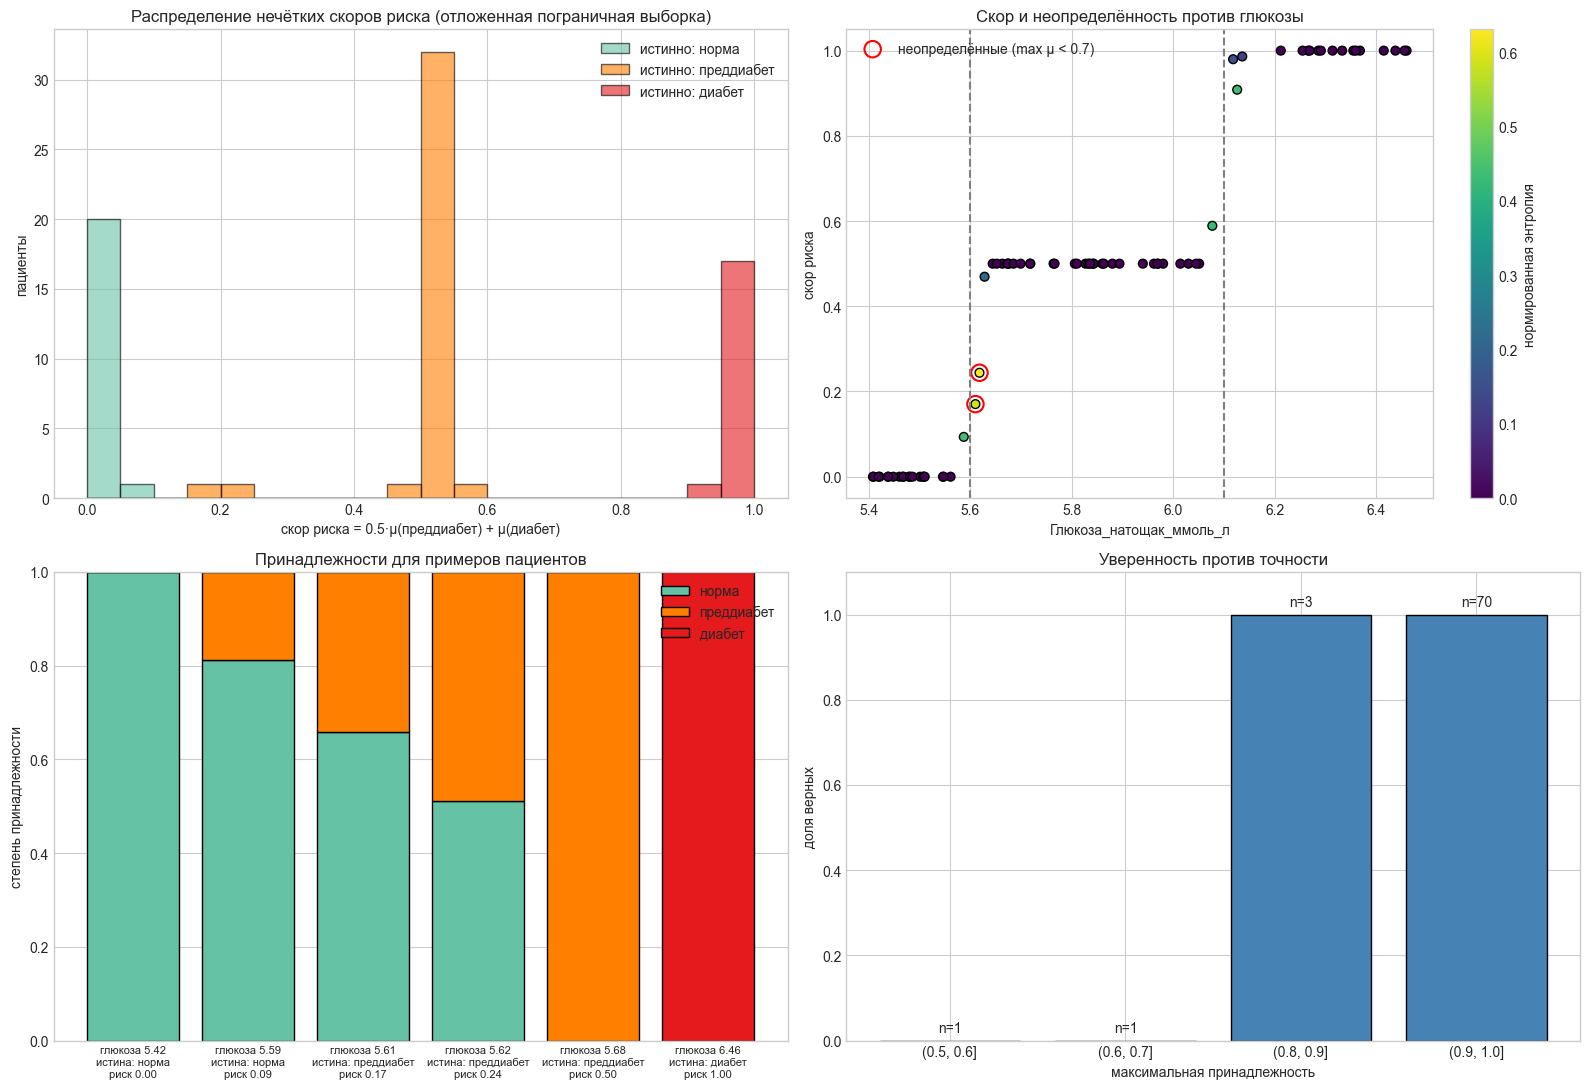

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for c, col in enumerate(['#66c2a5', '#ff7f00', '#e41a1c']):
    axes[0, 0].hist(risk_ho[yb_ho == c], bins=np.linspace(0, 1, 21), alpha=0.6, color=col,
                    edgecolor='black', label=f'истинно: {CLASS_NAMES[c]}')
axes[0, 0].set_xlabel('скор риска = 0.5·μ(преддиабет) + μ(диабет)')
axes[0, 0].set_ylabel('пациенты'); axes[0, 0].legend()
axes[0, 0].set_title('Распределение нечётких скоров риска (отложенная пограничная выборка)')

sc = axes[0, 1].scatter(Xb_ho[GLU], risk_ho, c=ent_ho, cmap='viridis', s=40, edgecolor='k')
axes[0, 1].scatter(Xb_ho[GLU][unc_ho], risk_ho[unc_ho], s=140, facecolors='none',
                   edgecolors='red', lw=1.5, label='неопределённые (max μ < 0.7)')
for t in [5.6, 6.1]:
    axes[0, 1].axvline(t, ls='--', color='grey')
plt.colorbar(sc, ax=axes[0, 1], label='нормированная энтропия')
axes[0, 1].set_xlabel(GLU); axes[0, 1].set_ylabel('скор риска')
axes[0, 1].set_title('Скор и неопределённость против глюкозы'); axes[0, 1].legend()

order = np.argsort(risk_ho)
examples = np.unique(np.r_[np.argsort(-ent_ho)[:3], order[[0, len(order) // 2, -1]]])
examples = examples[np.argsort(risk_ho[examples])]
bottom = np.zeros(len(examples))
for c, col in enumerate(['#66c2a5', '#ff7f00', '#e41a1c']):
    axes[1, 0].bar(range(len(examples)), mu_ho[examples, c], bottom=bottom, color=col,
                   edgecolor='black', label=CLASS_NAMES[c])
    bottom += mu_ho[examples, c]
axes[1, 0].set_xticks(range(len(examples)))
axes[1, 0].set_xticklabels([f'глюкоза {Xb_ho[GLU].iloc[i]:.2f}\nистина: {CLASS_NAMES[yb_ho[i]]}\n'
                            f'риск {risk_ho[i]:.2f}' for i in examples], fontsize=8)
axes[1, 0].set_ylabel('степень принадлежности'); axes[1, 0].legend()
axes[1, 0].set_title('Принадлежности для примеров пациентов')

bins = pd.cut(mu_ho.max(1), [0.33, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], include_lowest=True)
rel = pd.DataFrame({'bin': bins, 'ok': hard_ho == yb_ho}).groupby('bin', observed=True)['ok'].agg(['mean', 'size'])
axes[1, 1].bar(rel.index.astype(str), rel['mean'], color='steelblue', edgecolor='black')
for i, (a, n) in enumerate(zip(rel['mean'], rel['size'])):
    axes[1, 1].text(i, a + 0.02, f'n={n}', ha='center')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_xlabel('максимальная принадлежность'); axes[1, 1].set_ylabel('доля верных')
axes[1, 1].set_title('Уверенность против точности')

plt.tight_layout(); save(fig, '09_fuzzy_knn.png'); plt.show()

In [21]:
fuzzy_full = FuzzyKNN(**best_fuzzy).fit(Xb, yb)
border_test = test[test[GLU].between(5.4, 6.5)].reset_index(drop=True)
mu_te = fuzzy_full.predict_membership(border_test[FUZZY_FEATURES])
risk_te, ent_te, unc_te = risk_and_uncertainty(mu_te)
fuzzy_out = pd.DataFrame({
    ID: border_test[ID],
    GLU: border_test[GLU],
    'mu_норма': mu_te[:, 0].round(3),
    'mu_преддиабет': mu_te[:, 1].round(3),
    'mu_диабет': mu_te[:, 2].round(3),
    'risk_score': risk_te.round(3),
    'entropy': ent_te.round(3),
    'uncertain': unc_te,
})
fuzzy_out.to_csv(out_dir / 'task1_fuzzy_knn_borderline_test.csv', index=False)
print(f'пограничных пациентов в test: {len(fuzzy_out)}, неопределённых: {unc_te.sum()}')
display(fuzzy_out.sort_values('entropy', ascending=False).head(10))

пограничных пациентов в test: 66, неопределённых: 1


,patient_id,Глюкоза_натощак_ммоль_л,mu_норма,mu_преддиабет,mu_диабет,risk_score,entropy,uncertain
27,460,5.595,0.546,0.454,0.000,0.227,0.627,True
44,692,5.584,0.763,0.237,0.000,0.118,0.498,False
31,499,5.588,0.768,0.232,0.000,0.116,0.494,False
29,470,5.580,0.777,0.223,0.000,0.112,0.483,False
55,872,5.606,0.221,0.779,0.000,0.389,0.481,False
30,491,6.124,0.000,0.203,0.797,0.899,0.459,False
49,804,5.606,0.174,0.826,0.000,0.413,0.421,False
41,679,6.076,0.000,0.903,0.097,0.548,0.289,False
36,591,5.612,0.088,0.912,0.000,0.456,0.271,False
2,63,5.570,0.949,0.051,0.000,0.026,0.184,False


## 5. Отчёт

**Предобработка.** Из признаков исключены все целевые столбцы (`prediction`, `Статус_глюкозы`, `Доклинический_риск`), в том числе присутствующие в test. Пропуски (4–6% в ЛПНП, ЛПВП, ТГ, СКФ) заполняются `IterativeImputer` с индикаторами пропуска, затем `StandardScaler`; всё внутри `Pipeline`, обучается только на train.

**Дисбаланс (18% высокого риска).** Стратифицированное разделение 80/20, `class_weight='balanced'`, порог выбран по out-of-fold вероятностям: максимум F1 при recall ≥ 0.90 (0.42).

**Модель.** По 5×3 CV лучшая — HistGradientBoosting (ROC-AUC 0.997) против SVM 0.971 и LogReg 0.969. На отложенной выборке (160 чел.): Accuracy, Recall, Specificity, Precision, F1, ROC-AUC = 1.00 (29 TP, 131 TN); базовая SVM — F1 0.82, 2 FN и 10 FP. На OOF ошибок больше (3 FN, 6 FP), поэтому реальное качество ближе к F1 ≈ 0.96.

**Важные признаки** (permutation): возраст, курение, глюкоза, ЛПНП, пол; ИМТ, ЛПВП, СКФ при них почти не добавляют информации.

**Слабые места.** Класс высокого риска малочислен: на отложенной выборке всего 29 случаев, оценка неустойчива. В нечётком KNN ошибки — на границе норма/преддиабет (5.6 ммоль/л).

**Нечёткий KNN** (5.4–6.5 ммоль/л, n=247): вес глюкозы в метрике, k=7, m=1.5 подобраны по CV log-loss. Accuracy 0.97, log-loss 0.03 против 0.77 и 0.45 у базовой версии. Скор риска = 0.5·μ(преддиабет)+μ(диабет); неопределённость — энтропия, случай неопределён при max μ < 0.7. Оба ошибочных прогноза отложенной выборки попали в неопределённые — флаг работает как сигнал «перепроверить».

**Клинические ограничения.** Данные симулированные: целевые метки, по-видимому, заданы правилами, отсюда почти идеальное качество, которое на реальных данных недостижимо. Модель лишь поддерживает, а не заменяет решение врача. Снижение порога уменьшает FN ценой роста FP (лишние обследования); выбор порога — клиническое, а не техническое решение. Статус глюкозы по одному измерению у порога ненадёжен — нужен повторный анализ/HbA1c.